In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [25]:
# 1. UPLOAD AND PREPARE DATA
print("Please upload 'Chocolate Sales.csv':")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

Please upload 'Chocolate Sales.csv':


Saving Dataset Sales.csv to Dataset Sales (1).csv


In [26]:
# Load and DOUBLE the dataset for improved training
df_raw = pd.read_csv(filename)
df = pd.concat([df_raw, df_raw], ignore_index=True)

In [27]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184


In [28]:
df.tail()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
2183,Karlen McCaffrey,Australia,Spicy Special Slims,17-May-22,"$4,410",323
2184,Jehu Rudeforth,USA,White Choc,07-Jun-22,"$6,559",119
2185,Ches Bonnell,Canada,Organic Choco Syrup,26-Jul-22,$574,217
2186,Dotty Strutley,India,Eclairs,28-Jul-22,"$2,086",384
2187,Karlen McCaffrey,India,70% Dark Bites,23-May-22,"$5,075",344


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2188 entries, 0 to 2187
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   2188 non-null   object
 1   Country        2188 non-null   object
 2   Product        2188 non-null   object
 3   Date           2188 non-null   object
 4   Amount         2188 non-null   object
 5   Boxes Shipped  2188 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 102.7+ KB


In [30]:
# Data Cleaning
df['Amount'] = df['Amount'].str.replace('$', '').str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Quarter'] = df['Date'].dt.quarter

sns.set(style="whitegrid")

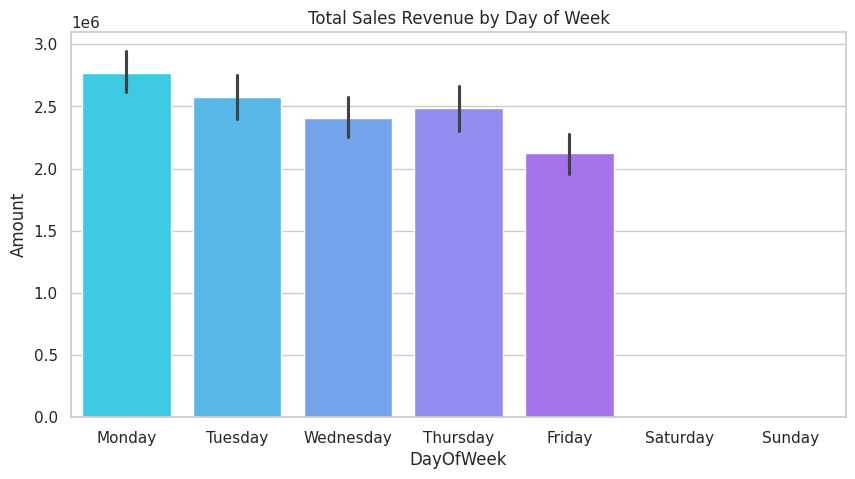

In [31]:
plt.figure(figsize=(10, 5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df, x='DayOfWeek', y='Amount', order=day_order, estimator=sum, palette='cool')
plt.title('Total Sales Revenue by Day of Week')
plt.show()

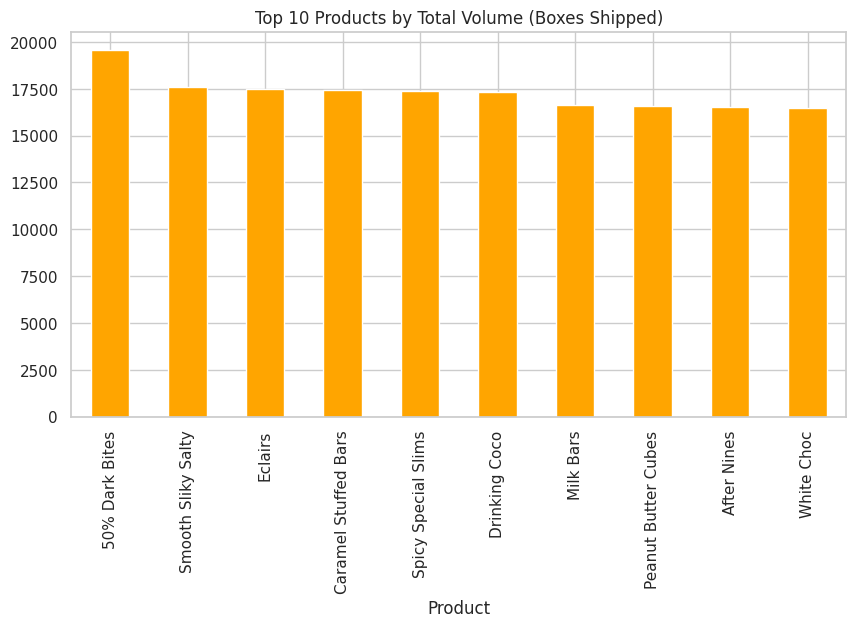

In [32]:
plt.figure(figsize=(10, 5))
df.groupby('Product')['Boxes Shipped'].sum().sort_values(ascending=False).head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Products by Total Volume (Boxes Shipped)')
plt.show()

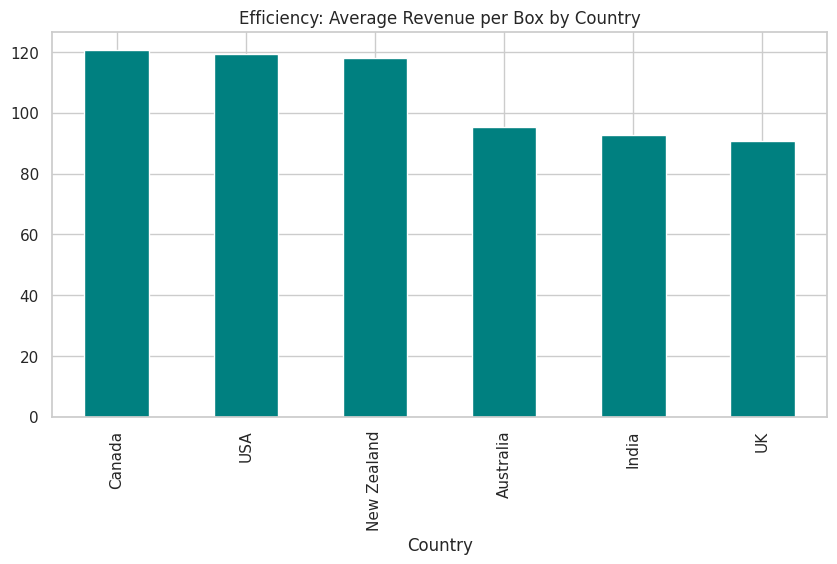

In [33]:
df['Amount_per_Box'] = df['Amount'] / df['Boxes Shipped']
plt.figure(figsize=(10, 5))
df.groupby('Country')['Amount_per_Box'].mean().sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title('Efficiency: Average Revenue per Box by Country')
plt.show()

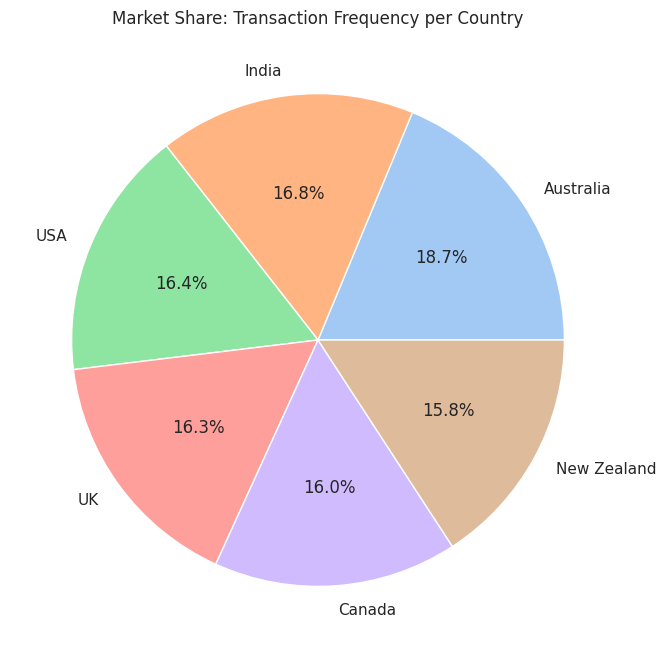

In [34]:
plt.figure(figsize=(8, 8))
df['Country'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Market Share: Transaction Frequency per Country')
plt.ylabel('')
plt.show()

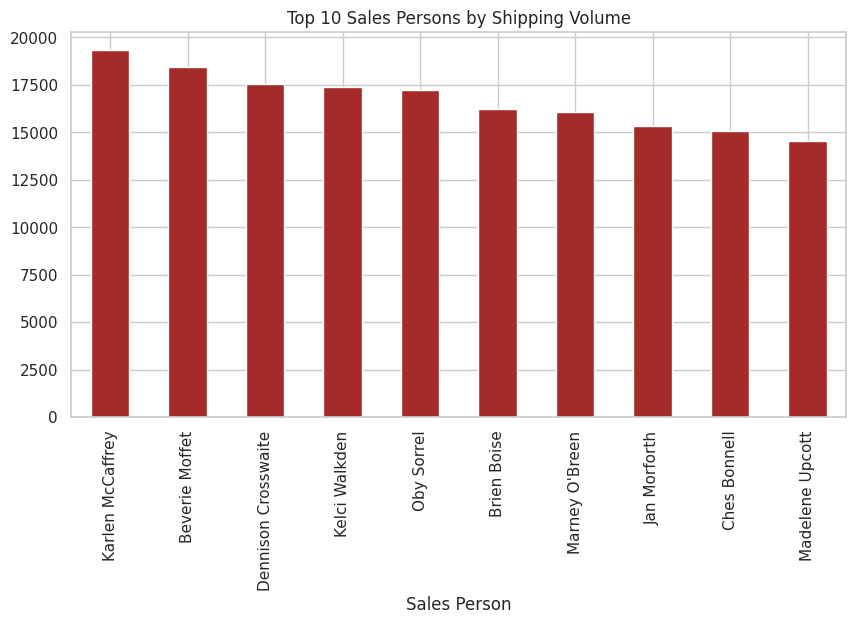

In [35]:
plt.figure(figsize=(10, 5))
df.groupby('Sales Person')['Boxes Shipped'].sum().nlargest(10).plot(kind='bar', color='brown')
plt.title('Top 10 Sales Persons by Shipping Volume')
plt.show()

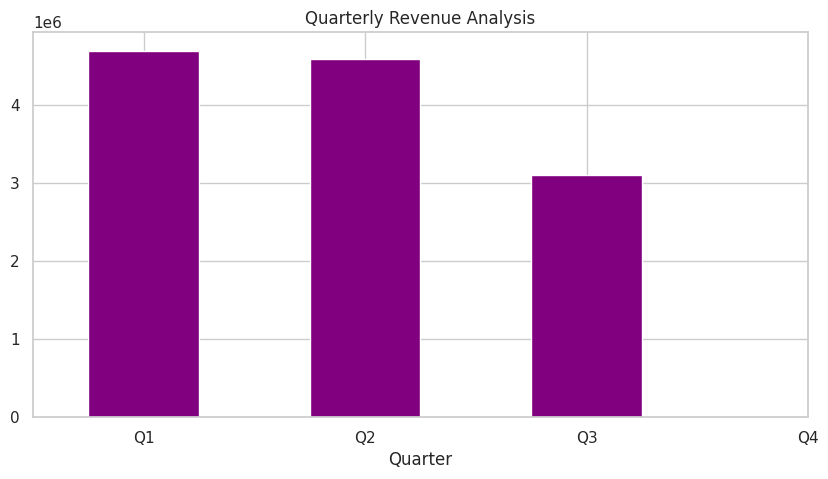

In [36]:
plt.figure(figsize=(10, 5))
df.groupby('Quarter')['Amount'].sum().plot(kind='bar', color='purple')
plt.title('Quarterly Revenue Analysis')
plt.xticks(ticks=[0,1,2,3], labels=['Q1', 'Q2', 'Q3', 'Q4'], rotation=0)
plt.show()

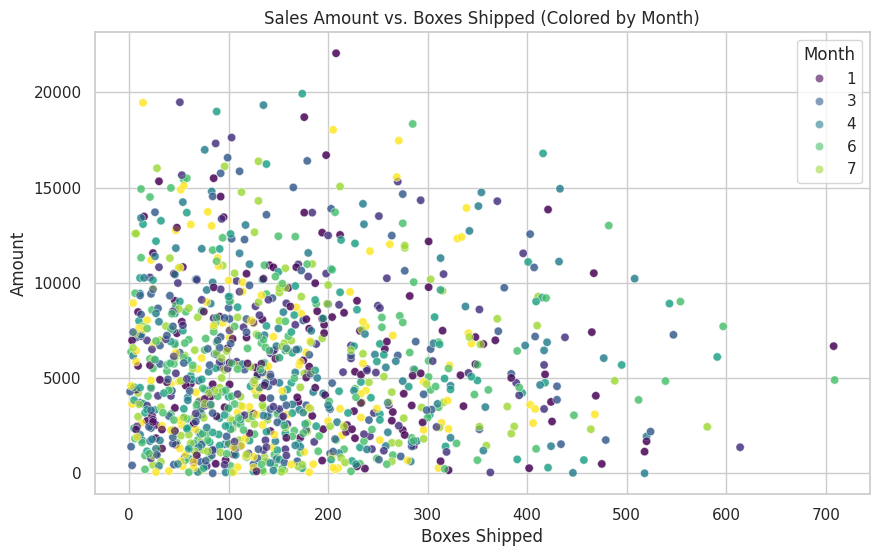

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Boxes Shipped', y='Amount', hue='Month', palette='viridis', alpha=0.6)
plt.title('Sales Amount vs. Boxes Shipped (Colored by Month)')
plt.show()

In [38]:
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# Loading the dataset (assuming 'Dataset Sales.csv' as per Bernard's notebook)
try:
    df_raw = pd.read_csv('Dataset Sales.csv')
    df = pd.concat([df_raw, df_raw], ignore_index=True) # Doubling for training as per original code

    # Cleaning 'Amount' and 'Date'
    df['Amount'] = df['Amount'].str.replace('$', '').str.replace(',', '').astype(float)
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')

    # Features and Target
    X = df[['Boxes Shipped']]
    y = df['Amount']

    print("✓ Dataset prepared for Regression.")
except Exception as e:
    print(f"Error loading data: {e}")

# Scaling (Mandatory for Neural Networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

✓ Dataset prepared for Regression.


In [39]:
# -----------------------------------------------------------------------------
# APPLYING UPDATED MODELS (Linear Regression & Neural Model)
# -----------------------------------------------------------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Neural Network (MLP)": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

results_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    results_list.append({
        "Model": name,
        "MSE": mean_squared_error(y_test, predictions),
        "MAE": mean_absolute_error(y_test, predictions),
        "R2 Score": r2_score(y_test, predictions)
    })


--- Model Performance Rank Table ---
               Model          MSE         MAE  R2 Score  Rank
   Linear Regression 1.635017e+07 3224.926478 -0.004002     1
Neural Network (MLP) 1.642289e+07 3230.211629 -0.008468     2


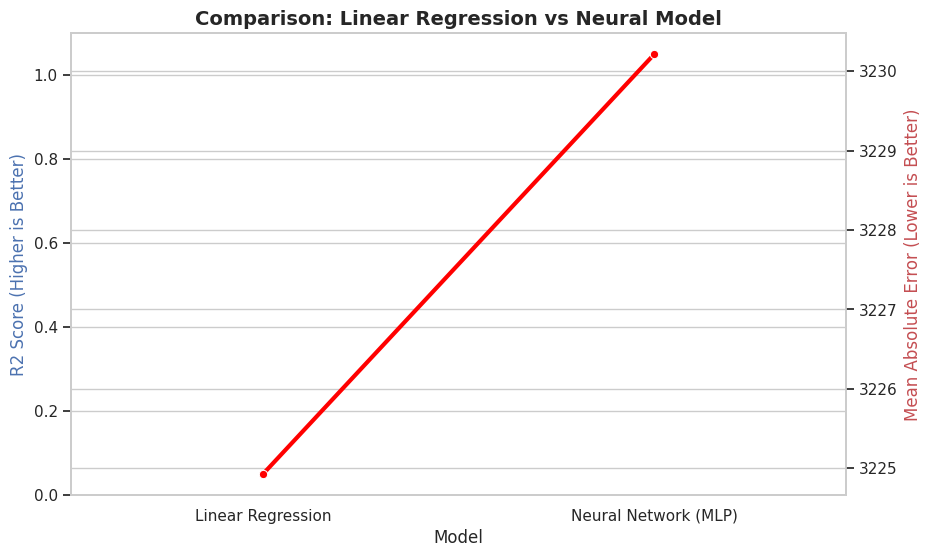

In [41]:
# Create Rank Table (Ranked by R2 Score - Higher is better)
results_df = pd.DataFrame(results_list)
results_df['Rank'] = results_df['R2 Score'].rank(ascending=False).astype(int)
results_df = results_df.sort_values(by='Rank')

print("\n--- Model Performance Rank Table ---")
print(results_df.to_string(index=False))

# Visualization: Metric Comparison
# Note: We plot R2 Score and MAE separately for better scale representation
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(data=results_df, x='Model', y='R2 Score', ax=ax1, palette='viridis', alpha=0.7)
ax1.set_ylabel('R2 Score (Higher is Better)', color='b', fontsize=12)
ax1.set_ylim(0, 1.1)

ax2 = ax1.twinx()
sns.lineplot(data=results_df, x='Model', y='MAE', ax=ax2, marker='o', color='red', linewidth=3)
ax2.set_ylabel('Mean Absolute Error (Lower is Better)', color='r', fontsize=12)

plt.title('Comparison: Linear Regression vs Neural Model', fontsize=14, fontweight='bold')
plt.show()